In [1]:
import scanpy as sc
import scvi
import numpy as np

adata = sc.read_h5ad(
    "../../data/obesity_subset_CEBPB_KIF11.h5ad"
)

print(adata)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 24325 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'


In [2]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor="seurat_v3",
    subset=True
)

print(adata)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


AnnData object with n_obs × n_vars = 24325 × 3000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


In [3]:
adata.obs["batch"] = adata.obs["SampleID"].astype(str)

adata.obs["n_guides"] = (
    adata.obs["num_features"]
    .astype(str)
    .astype("category")
)

In [4]:
print(scvi.__version__)

1.4.2


In [5]:
train_perts = [
    "NC",
    "NC+NC",
    "CEBPB",
    "KIF11",
    "CEBPB+NC",
    "KIF11+NC"
]

adata_train = adata[
    adata.obs["gene"].isin(train_perts)
].copy()

adata_test = adata[
    adata.obs["gene"] == "CEBPB+KIF11"
].copy()

In [6]:
adata_train.obs["batch"] 

cell
P1_AAACGAATCCTGGTCC-1      TF15_MOI2_1
P1_AAACGATGTAGCAGAC-1      TF15_MOI2_1
P1_AAACGATGTTAGGCCC-1      TF15_MOI2_1
P1_AAACGATGTTATGCGT-1      TF15_MOI2_1
P1_AAACGATGTTGTAGCT-1      TF15_MOI2_1
                              ...     
P12_TGTGCCCTCGACATGC-1    TF15_MOI2_12
P12_TGTGGTTGTTAACGTC-1    TF15_MOI2_12
P12_TGTGTACGTCATGTCG-1    TF15_MOI2_12
P12_TGTGTTAGTCTGGTCA-1    TF15_MOI2_12
P12_TGTGTTAGTTATCCAA-1    TF15_MOI2_12
Name: batch, Length: 24283, dtype: object

In [7]:
scvi.model.SCVI.setup_anndata(
    adata_train,
    layer='counts',   # 因為 counts 已在 X
    batch_key="batch",
    categorical_covariate_keys=["n_guides"]
)
vae = scvi.model.SCVI(
    adata_train,
    n_latent=50
)
vae.train(
    max_epochs=200,
    accelerator="mps",
    devices=1,
    batch_size=256,
    early_stopping=True
)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usual. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs

Epoch 200/200: 100%|██████████| 200/200 [07:03<00:00,  2.19s/it, v_num=1, train_loss=2.43e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [07:03<00:00,  2.12s/it, v_num=1, train_loss=2.43e+3]


In [8]:
z_train = vae.get_latent_representation(adata_train)

In [9]:
import pandas as pd

latent_df = pd.DataFrame(
    z_train,
    index=adata_train.obs_names
)

latent_df["gene"] = adata_train.obs["gene"].values

In [10]:
latent_df

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,gene
cell,,,,,,,,,,,,,,,,,,,,,
P1_AAACGAATCCTGGTCC-1,0.585291,-1.280644,1.597075,-0.883349,0.736986,1.107108,0.902766,-0.437251,-1.057230,-0.273204,...,-0.102122,1.538182,1.656824,-0.605873,-0.407191,0.653887,1.420594,0.373635,0.204760,CEBPB
P1_AAACGATGTAGCAGAC-1,-0.162557,0.890362,1.405463,-0.081123,1.916624,-0.032016,-0.594495,-0.660733,0.562375,-1.085142,...,-2.610894,-1.005070,1.120222,-1.047677,-0.826163,-2.181262,0.030551,0.615936,-0.240628,NC
P1_AAACGATGTTAGGCCC-1,-0.143628,-0.043459,-0.531773,-0.604031,-1.256630,0.558056,0.364586,-2.099229,0.283861,0.284595,...,0.216992,0.635148,-1.815317,0.529265,0.385391,-0.058370,1.361046,0.349199,0.492675,NC
P1_AAACGATGTTATGCGT-1,-0.608182,-0.731126,0.342763,1.450643,1.608000,-0.520168,0.336813,0.615886,-1.008046,-1.293193,...,-0.245519,-0.927297,0.689492,1.471456,0.686037,-1.145534,-0.532311,-0.797233,0.550980,NC
P1_AAACGATGTTGTAGCT-1,0.168928,1.454000,0.274039,-0.069807,-1.553495,0.171298,1.189952,0.732102,-0.821019,-0.286427,...,-0.244276,-1.744291,0.232527,0.273635,-0.023589,-0.134384,0.220542,-0.600689,-1.295704,NC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P12_TGTGCCCTCGACATGC-1,1.766234,0.377626,0.888005,0.553132,-0.276341,-0.058823,0.974348,-0.797711,0.940204,-0.769217,...,-0.015837,-0.097602,-1.753697,-1.923464,-0.298857,-0.883677,-1.047282,0.255984,0.797474,NC
P12_TGTGGTTGTTAACGTC-1,-0.985781,-1.363168,0.050506,0.425575,-0.823969,0.050892,-0.362249,1.014184,0.324753,-0.030067,...,-0.333400,-2.135866,1.329627,1.058062,0.718560,0.298259,-0.477554,-0.580132,-0.057337,NC
P12_TGTGTACGTCATGTCG-1,0.258406,0.492646,0.344593,0.116795,-0.020474,0.880835,0.527286,-1.646245,0.767315,1.682338,...,0.221983,0.572483,-0.550084,0.725393,0.103156,0.213967,-0.022456,-0.339688,2.082110,NC


In [11]:
def get_latent_subset(gene):
    
    mask = (
        adata_train.obs["gene"] == gene
    )

    return z_train[mask]

In [96]:
states = ["pre_adipo", "adipo", "lipo", "other"]

co_occurrence = (
    adata_train.obs[states]
    .value_counts()
    .reset_index()
    .rename(columns={0: "count"})
)

co_occurrence.sort_values("count", ascending=False).head(20)

,pre_adipo,adipo,lipo,other,count
0,0,0,0,1,12061
1,1,0,0,0,7368
2,0,1,0,0,3817
3,0,1,1,0,1037


In [97]:
0.3072907450008848+0.1686427181029906+0.5240665368961246+0.0312334100159263,

(1.0312334100159264,)

In [82]:
def get_latent_subset(gene):
    
    mask = (
        adata_train.obs["gene"] == gene
    )

    return {
        "z": z_train[mask],
        "obs": adata_train.obs.loc[mask, [
            "pre_adipo",
            "adipo",
            "lipo",
            "other"
        ]]
    }

In [83]:
z_NC = get_latent_subset("NC")

z_NCNC = get_latent_subset("NC+NC")

z_CEBPB = get_latent_subset("CEBPB")

z_KIF11 = get_latent_subset("KIF11")

z_CEBPB_NC = get_latent_subset("CEBPB+NC")

z_KIF11_NC = get_latent_subset("KIF11+NC")

In [84]:
import pandas as pd
import numpy as np

latent_dict = {
    "NC": z_NC,
    "NC+NC": z_NCNC,
    "CEBPB": z_CEBPB,
    "KIF11": z_KIF11,
    "CEBPB+NC": z_CEBPB_NC,
    "KIF11+NC": z_KIF11_NC,
}

Z = np.vstack([
    v["z"] for v in latent_dict.values()
])

gene_labels = np.concatenate([
    np.repeat(k, v["z"].shape[0])
    for k,v in latent_dict.items()
])

obs_concat = pd.concat([
    v["obs"] for v in latent_dict.values()
])

obs_concat["gene"] = gene_labels

In [88]:
import umap

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=0
)

Z_umap = reducer.fit_transform(Z)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


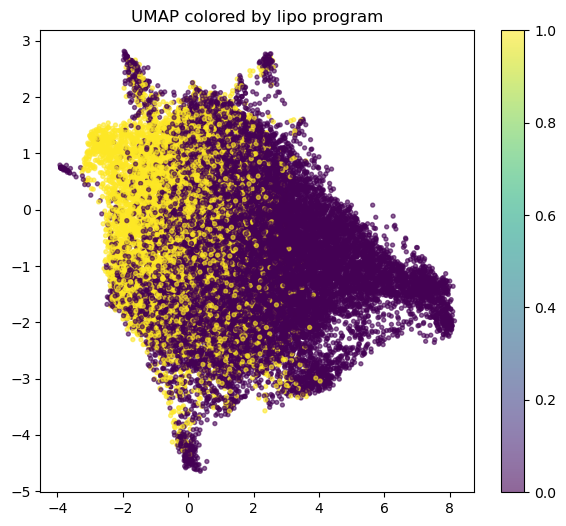

In [98]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    Z_umap[:,0],
    Z_umap[:,1],
    c=obs_concat["pre_adipo"],
    s=8,
    alpha=0.6
)

plt.title("UMAP colored by lipo program")

plt.colorbar()

plt.show()

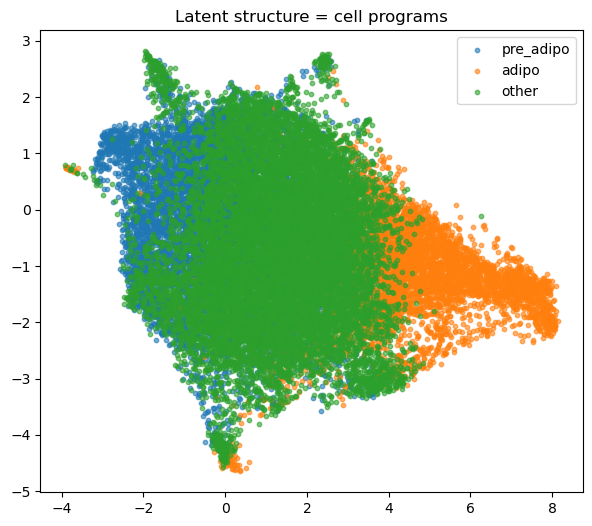

In [94]:
state = obs_concat[
    ["pre_adipo","adipo","lipo","other"]
].idxmax(axis=1)

plt.figure(figsize=(7,6))

for s in state.unique():

    idx = state == s

    plt.scatter(
        Z_umap[idx,0],
        Z_umap[idx,1],
        label=s,
        s=10,
        alpha=0.6
    )

plt.legend()

plt.title("Latent structure = cell programs")

plt.show()

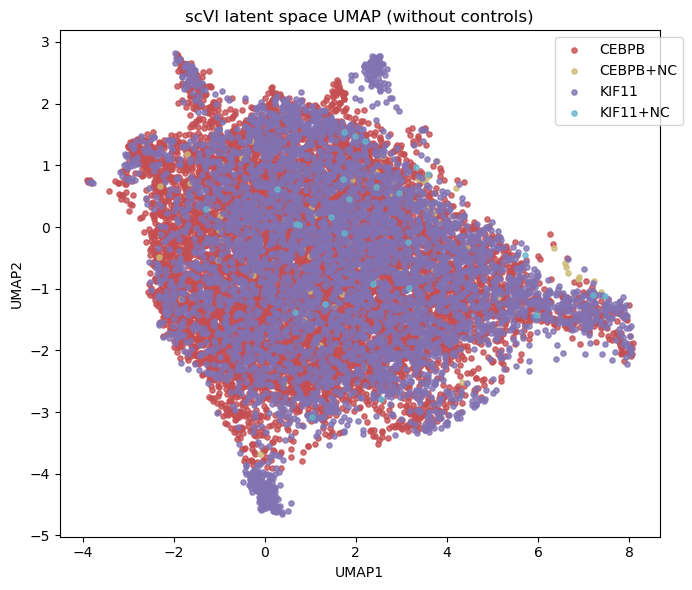

In [80]:
# ---------- plot ----------
plt.figure(figsize=(7,6))

exclude = ["NC", "NC+NC"]

unique_labels = np.unique(labels)

for lab in unique_labels:

    if lab in exclude:
        continue

    idx = labels == lab

    plt.scatter(
        Z_umap[idx, 0],
        Z_umap[idx, 1],
        label=lab,
        alpha=0.8,
        s=14,
        color=color_map[lab]
    )

plt.legend(bbox_to_anchor=(1.05, 1))
plt.title("scVI latent space UMAP (without controls)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.tight_layout()
plt.show()

In [13]:
gene_to_idx = {
    "CEBPB":0,
    "KIF11":1,
    "NC":2
}

In [14]:
import numpy as np

def encode_condition(pert):

    genes = pert.split("+")

    vec = np.zeros(3)

    for g in genes:

        vec[gene_to_idx[g]] += 1

    return vec

In [15]:
pairs = []

def add_pairs(source, target, condition):

    n = min(len(source), len(target))

    for i in range(n):

        pairs.append({

            "z0": source[i],
            "z1": target[i],
            "cond": encode_condition(condition)

        })

In [16]:
add_pairs(z_NC, z_CEBPB, "CEBPB")

add_pairs(z_NC, z_KIF11, "KIF11")

add_pairs(z_NCNC, z_CEBPB_NC, "CEBPB+NC")

add_pairs(z_NCNC, z_KIF11_NC, "KIF11+NC")

In [17]:
import torch
from torch.utils.data import Dataset

class FlowDataset(Dataset):

    def __init__(self, pairs):

        self.z0 = torch.tensor(
            [p["z0"] for p in pairs],
            dtype=torch.float32
        )

        self.z1 = torch.tensor(
            [p["z1"] for p in pairs],
            dtype=torch.float32
        )

        self.cond = torch.tensor(
            [p["cond"] for p in pairs],
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.z0)

    def __getitem__(self, idx):

        return (
            self.z0[idx],
            self.z1[idx],
            self.cond[idx]
        )

In [18]:
dataset = FlowDataset(pairs)

/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_56134/2218256038.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/torch/csrc/utils/tensor_new.cpp:256.)
  self.z0 = torch.tensor(


In [19]:
import torch.nn as nn

class FlowMLP(nn.Module):

    def __init__(
        self,
        latent_dim,
        cond_dim,
        hidden_dim=128
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                latent_dim + cond_dim + 1,
                hidden_dim
            ),

            nn.SiLU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.SiLU(),

            nn.Linear(
                hidden_dim,
                latent_dim
            )

        )

    def forward(
        self,
        z,
        t,
        cond
    ):

        x = torch.cat(
            [
                z,
                cond,
                t
            ],
            dim=1
        )

        return self.net(x)
    
def flow_matching_loss(
    model,
    z0,
    z1,
    cond
):

    batch_size = z0.shape[0]

    t = torch.rand(
        batch_size,
        1,
        device=z0.device
    )

    zt = (1-t)*z0 + t*z1

    target_v = z1 - z0

    pred_v = model(
        zt,
        t,
        cond
    )

    loss = torch.mean(
        (pred_v - target_v)**2
    )

    return loss

In [20]:
from torch.utils.data import DataLoader

loader = DataLoader(

    dataset,

    batch_size=128,

    shuffle=True
)

In [24]:
latent_dim = pairs[0]["z0"].shape[0]

cond_dim = pairs[0]["cond"].shape[0]

model = FlowMLP(

    latent_dim,

    cond_dim
)

In [25]:
device = "mps"

model.to(device)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3
)
for epoch in range(200):
    
    losses = []

    for z0, z1, cond in loader:

        z0 = z0.to(device)

        z1 = z1.to(device)

        cond = cond.to(device)

        loss = flow_matching_loss(

            model,

            z0,

            z1,

            cond
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(
            loss.item()
        )

    if epoch % 20 == 0:

        print(
            epoch,
            sum(losses)/len(losses)
        )

0 1.6669777733939035
20 1.3145384368442354
40 1.2953920932043166
60 1.28151748975118
80 1.2764882598604474
100 1.2761296896707444
120 1.271751442409697
140 1.2644631771814256
160 1.2625837473642259
180 1.2617060456957137


In [26]:
def sample_flow(
    model,
    z0,
    cond,
    n_steps=50
):

    device = next(model.parameters()).device

    z = z0.to(device)

    cond = cond.to(device)

    dt = 1.0/n_steps

    for i in range(n_steps):

        t = torch.ones(

            len(z),

            1,

            device=device

        ) * (i/n_steps)

        v = model(
            z,
            t,
            cond
        )

        z = z + dt*v

    return z

In [60]:
z_NCNC.shape

(28, 50)

In [27]:
cond_combo = encode_condition(

    "CEBPB+KIF11"
)
cond_combo = torch.tensor(

    cond_combo,

    dtype=torch.float32

).unsqueeze(0)

z_source = torch.tensor(

    z_NCNC[:100],

    dtype=torch.float32
)

cond_batch = cond_combo.repeat(

    len(z_source),

    1
)

z_pred = sample_flow(

    model,

    z_source,

    cond_batch
)

In [28]:
z_pred_cpu = z_pred.detach().cpu().numpy()
import torch

z_pred_torch = torch.tensor(
    z_pred_cpu,
    dtype=torch.float32
)

z_pred_torch = z_pred_torch.to(device)

In [29]:
library_mean = adata_train.obs["nCount_RNA"].mean()

library = torch.ones(
    z_pred_torch.shape[0],
    1,
    device=device
) * library_mean

In [49]:
import anndata as ad
import numpy as np


############################################
# latent → numpy
############################################

z_pred_np = (
    z_pred
    .detach()
    .cpu()
    .numpy()
)


############################################
# 建立 fake adata
############################################

adata_fake = ad.AnnData(

    X = np.zeros(
        (z_pred_np.shape[0], adata_train.n_vars)
    ),

    var = adata_train.var.copy()

)


############################################
# 必須包含 counts layer
############################################

adata_fake.layers["counts"] = np.zeros_like(
    adata_fake.X
)


############################################
# latent
############################################

adata_fake.obsm["X_scVI"] = z_pred_np


############################################
# batch
############################################

batch_value = (

    adata_train.obs
    .loc[
        adata_train.obs["gene"] == "NC+NC",
        "batch"
    ]
    .mode()[0]

)

adata_fake.obs["batch"] = batch_value

adata_fake.obs["batch"] = (
    adata_fake.obs["batch"]
    .astype("category")
)


############################################
# n_guides
# CEBPB+KIF11 = 2 guides
############################################

adata_fake.obs["n_guides"] = "2"

adata_fake.obs["n_guides"] = (
    adata_fake.obs["n_guides"]
    .astype("category")
)


############################################
# decode expression
############################################

pred_expr = vae.get_normalized_expression(

    adata_fake,

    transform_batch=batch_value,

    library_size=1e5,

    return_numpy=True

)


############################################
# competition format
############################################

pred_expr = np.log2(1 + pred_expr)


print("pred shape:", pred_expr.shape)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
pred shape: (28, 3000)


In [51]:
pred_expr

array([[5.560243  , 5.369155  , 6.3218822 , ..., 1.3081062 , 1.2396406 ,
        0.8261465 ],
       [5.6139784 , 5.388627  , 6.3558564 , ..., 1.1888149 , 1.2377874 ,
        0.84933335],
       [5.602261  , 5.5924907 , 6.3203945 , ..., 1.4100778 , 1.2383459 ,
        0.92535913],
       ...,
       [5.5418663 , 5.394804  , 6.364005  , ..., 1.3170993 , 1.2714334 ,
        0.8014459 ],
       [5.690575  , 5.460298  , 6.4103875 , ..., 1.3820913 , 1.2091802 ,
        0.85213673],
       [5.690806  , 5.5606394 , 6.3098063 , ..., 1.3397084 , 1.2563525 ,
        0.85753894]], shape=(28, 3000), dtype=float32)

In [54]:
import pandas as pd

df = pd.DataFrame(
    adata_test.X.toarray(),
    index=adata_test.obs_names,
    columns=adata_test.var_names
)

df.head()

gene,SDF4,MXRA8,MRPL20,ANKRD65,GNB1,AL590822.2,AL590438.1,TP73,AL031847.1,AL591163.1,...,BCAP31,RENBP,FAM50A,RPS4Y1,LINC00278,TTTY12,PRY2,TTTY4,TTTY17C,AC136612.1
cell,,,,,,,,,,,,,,,,,,,,,
P1_TCGCCATCATCACTGC-1,4.009258,5.219060,3.709556,0.0,4.468857,0.0,0.0,0.0,0.0,0.0,...,4.816876,0.0,3.330817,4.468857,0.0,0.0,0.0,0.0,0.0,0.0
P2_CTACGCCTCAGGTCCG-1,5.257421,3.605881,3.990987,0.0,3.990987,0.0,0.0,0.0,0.0,0.0,...,4.545383,0.0,4.294653,4.545383,0.0,0.0,0.0,0.0,0.0,0.0
P2_CTTCGCGCATAGGTTA-1,3.572935,4.511009,3.572935,0.0,4.260574,0.0,0.0,0.0,0.0,0.0,...,3.957341,0.0,3.957341,4.910140,0.0,0.0,0.0,0.0,0.0,0.0
P2_GTAACCGCAAGTGGCC-1,3.744302,4.689445,5.090436,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,3.744302,0.0,3.744302,3.744302,0.0,0.0,0.0,0.0,0.0,0.0
P2_GTCCCTTGTGCGCCAT-1,4.720989,6.269013,4.974877,0.0,4.412672,0.0,0.0,0.0,0.0,0.0,...,3.478867,0.0,4.720989,5.378400,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(X, Y, gamma=1):

    XX = rbf_kernel(X, X, gamma)

    YY = rbf_kernel(Y, Y, gamma)

    XY = rbf_kernel(X, Y, gamma)

    return XX.mean() + YY.mean() - 2*XY.mean()


mmd = compute_mmd(

    adata_test.X,

    pred_expr,

    gamma=1/pred_expr.shape[1]

)

print("MMD:", mmd)

MMD: 1.065997582786443


In [59]:
import numpy as np
from scipy.stats import pearsonr

real_mean = df.mean(axis=0)

pred_mean = pred_expr.mean(axis=0)

corr = pearsonr(real_mean, pred_mean)[0]

print("mean gene correlation:", corr)


control_mask = adata_train.obs["gene"] == "NC+NC"

control_expr = adata_train[control_mask].X

control_mean = control_expr.mean(axis=0)

real_delta = real_mean - control_mean

pred_delta = pred_mean - control_mean

delta_corr = pearsonr(

    real_delta,

    pred_delta

)[0]

print("delta correlation:", delta_corr)

mean gene correlation: 0.9290555785101152


ValueError: Length of values (1) does not match length of index (3000)

In [57]:
import numpy as np

X_real = df
X_pred = pred_expr

X_all = np.vstack([

    X_real,

    X_pred

])

labels = (

    ["real"] * X_real.shape[0]

    +

    ["pred"] * X_pred.shape[0]

)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_all)

print("explained variance:", pca.explained_variance_ratio_)

explained variance: [0.60471383 0.02973359]


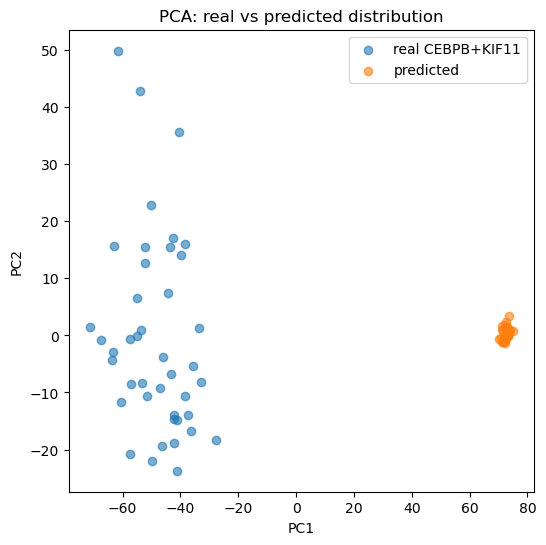

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(

    X_pca[:X_real.shape[0], 0],

    X_pca[:X_real.shape[0], 1],

    label="real CEBPB+KIF11",

    alpha=0.6

)

plt.scatter(

    X_pca[X_real.shape[0]:, 0],

    X_pca[X_real.shape[0]:, 1],

    label="predicted",

    alpha=0.6

)

plt.legend()

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("PCA: real vs predicted distribution")

plt.show()

In [63]:
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad("../../data/obesity_subset_CEBPB_KIF11.h5ad")

# 確認 categories
print(adata.obs["gene"].cat.categories)

# 只保留 control cells
adata_ctrl = adata[adata.obs["gene"].isin(["NC", "NC+NC"])].copy()

print(adata_ctrl)

Index(['CEBPB', 'CEBPB+KIF11', 'CEBPB+NC', 'KIF11', 'KIF11+NC', 'NC', 'NC+NC'], dtype='object')
AnnData object with n_obs × n_vars = 8688 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'


In [64]:
sc.pp.highly_variable_genes(
    adata_ctrl,
    n_top_genes=3000,
    flavor="seurat_v3"
)

adata_ctrl = adata_ctrl[:, adata_ctrl.var.highly_variable].copy()

sc.pp.scale(adata_ctrl, max_value=10)

sc.tl.pca(adata_ctrl, n_comps=50)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/opt/anaconda3/envs/X-Cells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [66]:
centroids = []

for (batch, gene), idx in adata_ctrl.obs.groupby(["SampleID", "gene"]).groups.items():

    # 把 cell barcodes → integer index
    pos = adata_ctrl.obs.index.get_indexer(idx)

    X = adata_ctrl.obsm["X_pca"][pos]

    centroid = X.mean(axis=0)

    centroids.append({
        "SampleID": batch,
        "gene": gene,
        "centroid": centroid
    })

centroids_df = pd.DataFrame(centroids)

print(centroids_df.head())

       SampleID   gene                                           centroid
0   TF15_MOI2_1     NC  [-0.10047147, 7.6483784, -2.0977156, 1.2459681...
1   TF15_MOI2_1  NC+NC  [21.109941, 5.509702, -9.51567, 0.48003975, -1...
2  TF15_MOI2_10     NC  [0.095903724, -8.3376465, 0.41273913, 1.110683...
3  TF15_MOI2_10  NC+NC  [1.7249622, -5.9556775, -4.0051894, 3.6861913,...
4  TF15_MOI2_11     NC  [-0.5764614, -9.269287, 1.6656297, 0.20908792,...


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_56134/1173001842.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (batch, gene), idx in adata_ctrl.obs.groupby(["SampleID", "gene"]).groups.items():


In [67]:
from scipy.spatial.distance import euclidean

distances = []

for batch in centroids_df["SampleID"].unique():

    nc = centroids_df[
        (centroids_df.SampleID == batch) &
        (centroids_df.gene == "NC")
    ]

    ncnc = centroids_df[
        (centroids_df.SampleID == batch) &
        (centroids_df.gene == "NC+NC")
    ]

    if len(nc) > 0 and len(ncnc) > 0:

        d = euclidean(
            nc.iloc[0].centroid,
            ncnc.iloc[0].centroid
        )

        distances.append({
            "SampleID": batch,
            "distance": d
        })

dist_df = pd.DataFrame(distances)

print(dist_df.sort_values("distance"))
print("mean distance:", dist_df.distance.mean())

       SampleID   distance
3   TF15_MOI2_2   6.147690
5   TF15_MOI2_4   7.951775
7   TF15_MOI2_6   8.323133
9   TF15_MOI2_9   9.375139
1  TF15_MOI2_10   9.782478
8   TF15_MOI2_7   9.970268
6   TF15_MOI2_5  11.840727
4   TF15_MOI2_3  12.950052
2  TF15_MOI2_12  14.137798
0   TF15_MOI2_1  24.875965
mean distance: 11.535502576828003


In [68]:
import pandas as pd

# count cells per condition
count_table = (
    adata.obs
    .groupby(["SampleID", "gene"])
    .size()
    .unstack(fill_value=0)
)

print(count_table[["NC", "NC+NC"]])

# 總數
total_counts = adata.obs["gene"].value_counts()[["NC", "NC+NC"]]

print("\nTotal cells:")
print(total_counts)

gene           NC  NC+NC
SampleID                
TF15_MOI2_1   735      1
TF15_MOI2_2   735      4
TF15_MOI2_3   712      2
TF15_MOI2_4   705      3
TF15_MOI2_5   744      2
TF15_MOI2_6   765      5
TF15_MOI2_7   731      4
TF15_MOI2_8   691      0
TF15_MOI2_9   727      2
TF15_MOI2_10  673      3
TF15_MOI2_11  700      0
TF15_MOI2_12  742      2

Total cells:
gene
NC       8660
NC+NC      28
Name: count, dtype: int64


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_56134/2028328642.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["SampleID", "gene"])


In [69]:
import numpy as np

# 只取 NC
adata_nc = adata[adata.obs["gene"] == "NC"].copy()

# 使用同樣 preprocessing
sc.pp.highly_variable_genes(adata_nc, n_top_genes=3000)
adata_nc = adata_nc[:, adata_nc.var.highly_variable]

sc.pp.scale(adata_nc)
sc.tl.pca(adata_nc)

# 計算 centroid
nc_centroids = {}

for batch in adata_nc.obs["SampleID"].unique():

    X = adata_nc.obsm["X_pca"][
        adata_nc.obs["SampleID"] == batch
    ]

    nc_centroids[batch] = X.mean(axis=0)

# pairwise distance
from scipy.spatial.distance import pdist, squareform

dist_nc = squareform(
    pdist(list(nc_centroids.values()))
)

dist_nc = pd.DataFrame(
    dist_nc,
    index=nc_centroids.keys(),
    columns=nc_centroids.keys()
)

print("NC vs NC distance between batches")
print(dist_nc)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/X-Cells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


NC vs NC distance between batches
              TF15_MOI2_1  TF15_MOI2_2  TF15_MOI2_3  TF15_MOI2_4  TF15_MOI2_5  \
TF15_MOI2_1      0.000000     1.949572     8.126876     8.258590     4.936046   
TF15_MOI2_2      1.949572     0.000000     6.393677     6.483877     3.157566   
TF15_MOI2_3      8.126876     6.393677     0.000000     1.279939     3.426373   
TF15_MOI2_4      8.258590     6.483877     1.279939     0.000000     3.489500   
TF15_MOI2_5      4.936046     3.157566     3.426373     3.489500     0.000000   
TF15_MOI2_6      3.201080     1.763806     5.048062     5.302851     2.137982   
TF15_MOI2_7      8.126012     6.313790     1.830956     1.340328     3.355241   
TF15_MOI2_8      1.734197     1.033328     6.641854     6.809989     3.499230   
TF15_MOI2_9      8.930196     7.618355     4.882027     4.867722     5.619126   
TF15_MOI2_10    11.128811     9.629687     5.355173     5.225366     7.208568   
TF15_MOI2_11    12.021837    10.434287     5.571766     5.318834     7.7737

In [70]:
adata_ncnc = adata[adata.obs["gene"] == "NC+NC"].copy()

sc.pp.highly_variable_genes(adata_ncnc, n_top_genes=3000)
adata_ncnc = adata_ncnc[:, adata_ncnc.var.highly_variable]

sc.pp.scale(adata_ncnc)
sc.tl.pca(adata_ncnc)

ncnc_centroids = {}

for batch in adata_ncnc.obs["SampleID"].unique():

    X = adata_ncnc.obsm["X_pca"][
        adata_ncnc.obs["SampleID"] == batch
    ]

    ncnc_centroids[batch] = X.mean(axis=0)

dist_ncnc = squareform(
    pdist(list(ncnc_centroids.values()))
)

dist_ncnc = pd.DataFrame(
    dist_ncnc,
    index=ncnc_centroids.keys(),
    columns=ncnc_centroids.keys()
)

print("\nNC+NC vs NC+NC distance between batches")
print(dist_ncnc)


NC+NC vs NC+NC distance between batches
              TF15_MOI2_1  TF15_MOI2_2  TF15_MOI2_3  TF15_MOI2_4  TF15_MOI2_5  \
TF15_MOI2_1      0.000000    48.122915    62.204069    58.995475    62.118823   
TF15_MOI2_2     48.122915     0.000000    53.853169    44.533828    46.805596   
TF15_MOI2_3     62.204069    53.853169     0.000000    63.149134    65.300319   
TF15_MOI2_4     58.995475    44.533828    63.149134     0.000000    56.233298   
TF15_MOI2_5     62.118823    46.805596    65.300319    56.233298     0.000000   
TF15_MOI2_6     48.038808    30.120731    53.884189    43.268773    46.246353   
TF15_MOI2_7     53.195344    39.661504    58.964438    51.159776    52.660181   
TF15_MOI2_9     54.713836    36.979133    57.606422    47.254340    50.096960   
TF15_MOI2_10    52.637080    39.923524    58.881392    51.274340    53.260678   
TF15_MOI2_12    53.213291    39.581760    58.871584    49.987518    53.047203   

              TF15_MOI2_6  TF15_MOI2_7  TF15_MOI2_9  TF15_MOI2_10  

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/X-Cells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/X-Cells/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


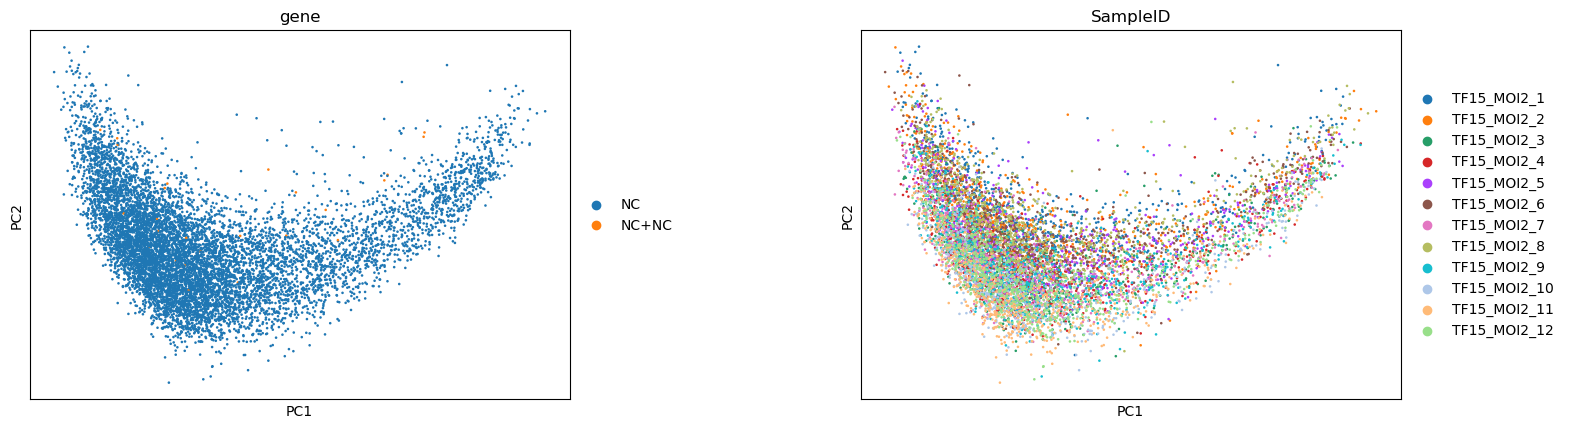

In [71]:
adata_ctrl = adata[
    adata.obs["gene"].isin(["NC", "NC+NC"])
].copy()

sc.pp.highly_variable_genes(adata_ctrl, n_top_genes=3000)
adata_ctrl = adata_ctrl[:, adata_ctrl.var.highly_variable]

sc.pp.scale(adata_ctrl)
sc.tl.pca(adata_ctrl)

sc.pl.pca(
    adata_ctrl,
    color=["gene", "SampleID"],
    wspace=0.4
)

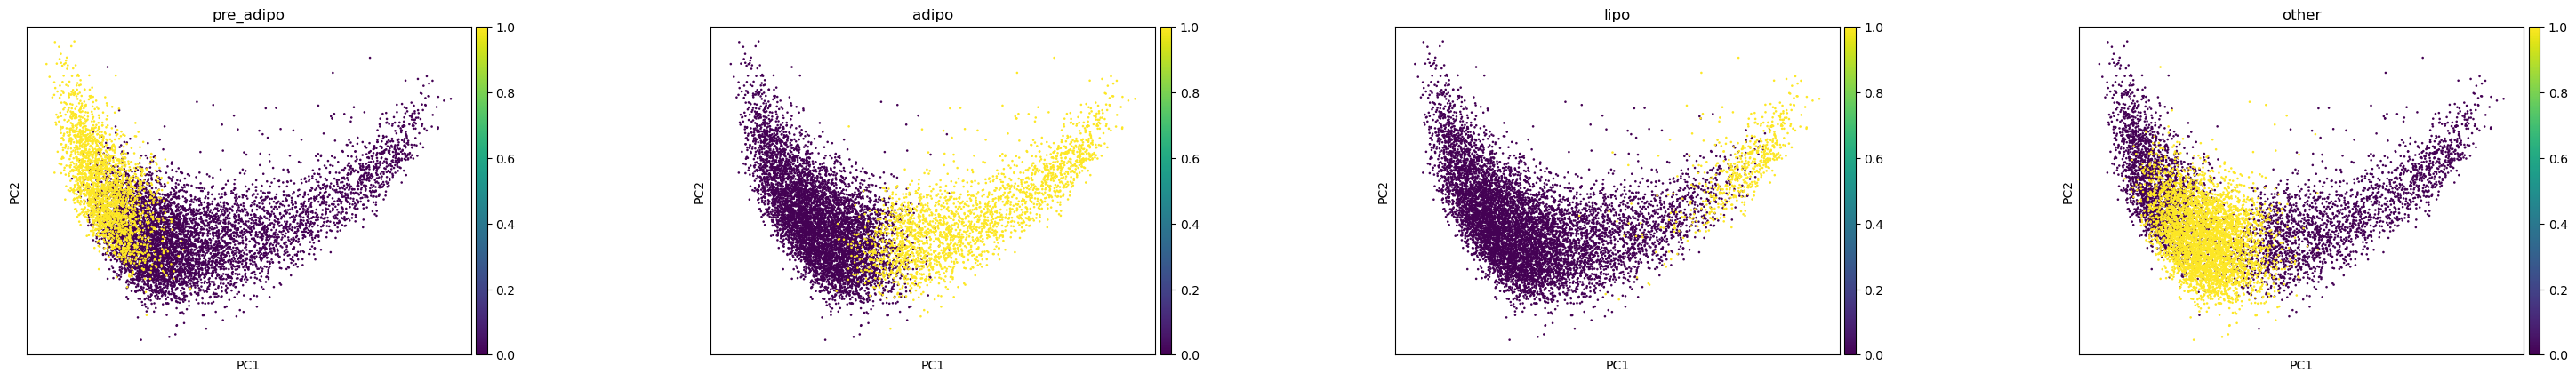

In [99]:
sc.pl.pca(
    adata_ctrl,
    color=    ["pre_adipo","adipo","lipo","other"],
    wspace=0.4
)